In [1]:
import pandas as pd

In [2]:
r"C:\Users\HomePC\Downloads\dirty_retail_sales_50_rows.csv"

'C:\\Users\\HomePC\\Downloads\\dirty_retail_sales_50_rows.csv'

In [3]:
df = pd.read_csv(r"C:\Users\HomePC\Downloads\dirty_retail_sales_50_rows.csv")

In [4]:
df.shape

(50, 10)

In [5]:
df.head()

,Transaction_ID,Customer_ID,Category,Item,Price_Per_Unit,Quantity,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN0001,CUST1022,Electronics,Bluetooth Speaker,10000.0,2.0,20000.0,Card,Lagos,2026-01-29
1,TXN0002,CUST1008,Home,Pillow,15000.0,1.0,15000.0,Cash,Uyo,2026-02-27
2,TXN0003,CUST1014,Home,Wall Clock,2500.0,2.0,5000.0,Transfer,LAGOS,2026-05-22
3,TXN0004,CUST1011,Clothing,Hoodie,10000.0,1.0,10000.0,Card,LAGOS,2026-04-21
4,TXN0005,CUST1004,Food,Cooking Oil,7500.0,3.0,22500.0,UNKNOWN,Uyo,2026-04-10


In [6]:
import numpy as np
import pandas as pd

# 1. Standardize Strings (Title Case & Whitespace Removal)
string_cols = ["Category", "Item", "Payment_Method", "Location"]

for col in string_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# 2. Convert 'Unknown' entries to true nulls (NaN)
df.replace(["Unknown", "Nan", "None"], np.nan, inplace=True)

# 3. Parse Dates
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

# 4. Standardize Numeric Columns & Recalculate Totals
df["Price_Per_Unit"] = pd.to_numeric(df["Price_Per_Unit"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Total_Spent"] = df["Price_Per_Unit"] * df["Quantity"]

# Verify cleaned output
df.head()

,Transaction_ID,Customer_ID,Category,Item,Price_Per_Unit,Quantity,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN0001,CUST1022,Electronics,Bluetooth Speaker,10000.0,2.0,20000.0,Card,Lagos,2026-01-29
1,TXN0002,CUST1008,Home,Pillow,15000.0,1.0,15000.0,Cash,Uyo,2026-02-27
2,TXN0003,CUST1014,Home,Wall Clock,2500.0,2.0,5000.0,Transfer,Lagos,2026-05-22
3,TXN0004,CUST1011,Clothing,Hoodie,10000.0,1.0,10000.0,Card,Lagos,2026-04-21
4,TXN0005,CUST1004,Food,Cooking Oil,7500.0,3.0,22500.0,NaN,Uyo,2026-04-10


In [7]:
print(df.isnull().sum())

Transaction_ID      0
Customer_ID         2
Category            0
Item                0
Price_Per_Unit      3
Quantity            2
Total_Spent         5
Payment_Method      2
Location            2
Transaction_Date    0
dtype: int64


In [8]:
# Check count of duplicate rows
print(df.duplicated().sum())

# Drop duplicates if any exist
df.drop_duplicates(inplace=True)

0


In [9]:
import numpy as np
import pandas as pd

# 1. Load the data (replace with your file name)
df = pd.read_csv(r"C:\Users\HomePC\Downloads\dirty_retail_sales_50_rows.csv")

# 2. Standardize Strings
string_cols = ["Category", "Item", "Payment_Method", "Location"]
for col in string_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# 3. Handle 'Unknown' Text Placeholders
df.replace(["Unknown", "Nan", "None"], np.nan, inplace=True)

# 4. Fix Numeric & Date Types
if "Transaction_Date" in df.columns:
    df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

df["Price_Per_Unit"] = pd.to_numeric(df["Price_Per_Unit"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Total_Spent"] = df["Price_Per_Unit"] * df["Quantity"]

# 5. Perform the Aggregations
category_sales = df.groupby("Category")["Total_Spent"].sum().reset_index()
location_sales = df.groupby("Location")["Total_Spent"].sum().reset_index()
payment_counts = df["Payment_Method"].value_counts()

# View output
print("--- Sales by Category ---")
print(category_sales)
print("\n--- Sales by Location ---")
print(location_sales)

--- Sales by Category ---
      Category  Total_Spent
0       Beauty      56500.0
1     Clothing      57000.0
2  Electronics     143500.0
3         Food     287500.0
4         Home     181500.0

--- Sales by Location ---
        Location  Total_Spent
0          Abuja      88000.0
1          Lagos     217500.0
2  Port Harcourt     132500.0
3            Uyo     230500.0


In [10]:
clean_df = df.copy()

In [11]:
clean_df=clean_df.dropna(axis=1,how="all")

In [12]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [13]:
clean_df.columns

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date'],
      dtype='object')

In [14]:
clean_df.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date
0,TXN0001,CUST1022,Electronics,Bluetooth Speaker,10000.0,2.0,20000.0,Card,Lagos,2026-01-29
1,TXN0002,CUST1008,Home,Pillow,15000.0,1.0,15000.0,Cash,Uyo,2026-02-27
2,TXN0003,CUST1014,Home,Wall Clock,2500.0,2.0,5000.0,Transfer,Lagos,2026-05-22
3,TXN0004,CUST1011,Clothing,Hoodie,10000.0,1.0,10000.0,Card,Lagos,2026-04-21
4,TXN0005,CUST1004,Food,Cooking Oil,7500.0,3.0,22500.0,NaN,Uyo,2026-04-10


In [15]:
clean_df.isnull().sum()

transaction_id      0
customer_id         2
category            0
item                0
price_per_unit      3
quantity            2
total_spent         5
payment_method      2
location            2
transaction_date    0
dtype: int64

In [16]:
clean_df.dtypes

transaction_id              object
customer_id                 object
category                    object
item                        object
price_per_unit             float64
quantity                   float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object

In [17]:
clean_df = clean_df.dropna(axis=1, how='all')

In [18]:
print(clean_df.columns.tolist())

['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [19]:
print(clean_df.head())

  transaction_id customer_id     category               item  price_per_unit  \
0        TXN0001    CUST1022  Electronics  Bluetooth Speaker         10000.0   
1        TXN0002    CUST1008         Home             Pillow         15000.0   
2        TXN0003    CUST1014         Home         Wall Clock          2500.0   
3        TXN0004    CUST1011     Clothing             Hoodie         10000.0   
4        TXN0005    CUST1004         Food        Cooking Oil          7500.0   

   quantity  total_spent payment_method location transaction_date  
0       2.0      20000.0           Card    Lagos       2026-01-29  
1       1.0      15000.0           Cash      Uyo       2026-02-27  
2       2.0       5000.0       Transfer    Lagos       2026-05-22  
3       1.0      10000.0           Card    Lagos       2026-04-21  
4       3.0      22500.0            NaN      Uyo       2026-04-10  


In [20]:
print(clean_df.columns.tolist())

['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [21]:
clean_df["transaction_id"]

0     TXN0001
1     TXN0002
2     TXN0003
3     TXN0004
4     TXN0005
5     TXN0006
6     TXN0007
7     TXN0008
8     TXN0009
9     TXN0010
10    TXN0011
11    TXN0012
12    TXN0013
13    TXN0014
14    TXN0015
15    TXN0016
16    TXN0017
17    TXN0018
18    TXN0019
19    TXN0020
20    TXN0021
21    TXN0022
22    TXN0023
23    TXN0024
24    TXN0025
25    TXN0026
26    TXN0027
27    TXN0028
28    TXN0029
29    TXN0030
30    TXN0031
31    TXN0032
32    TXN0033
33    TXN0034
34    TXN0035
35    TXN0036
36    TXN0037
37    TXN0038
38    TXN0039
39    TXN0040
40    TXN0041
41    TXN0042
42    TXN0043
43    TXN0044
44    TXN0045
45    TXN0046
46    TXN0047
47    TXN0048
48    TXN0049
49    TXN0050
Name: transaction_id, dtype: object

In [22]:
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print(clean_df.head())

Rows: 50
Columns: 10
  transaction_id customer_id     category               item  price_per_unit  \
0        TXN0001    CUST1022  Electronics  Bluetooth Speaker         10000.0   
1        TXN0002    CUST1008         Home             Pillow         15000.0   
2        TXN0003    CUST1014         Home         Wall Clock          2500.0   
3        TXN0004    CUST1011     Clothing             Hoodie         10000.0   
4        TXN0005    CUST1004         Food        Cooking Oil          7500.0   

   quantity  total_spent payment_method location transaction_date  
0       2.0      20000.0           Card    Lagos       2026-01-29  
1       1.0      15000.0           Cash      Uyo       2026-02-27  
2       2.0       5000.0       Transfer    Lagos       2026-05-22  
3       1.0      10000.0           Card    Lagos       2026-04-21  
4       3.0      22500.0            NaN      Uyo       2026-04-10  


In [23]:
text_columns = [
    "customer_id",
    "category",
    "item",
    "payment_method",
    "location"
]

for col in text_columns:
    clean_df[col] = clean_df[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Text spaces cleaned successfully.")


Text spaces cleaned successfully.


In [24]:
clean_df["location"] = clean_df["location"].apply(
    lambda x: x.strip().title() if isinstance(x, str) else x
)

print(clean_df["location"].value_counts(dropna=False))

Uyo              16
Lagos            14
Port Harcourt     9
Abuja             9
NaN               2
Name: location, dtype: int64


In [25]:
print("Payment Methods:")
print(clean_df["payment_method"].unique())

print("\nLocations:")
print(clean_df["location"].unique())

Payment Methods:
['Card' 'Cash' 'Transfer' nan 'Bank Transfer']

Locations:
['Lagos' 'Uyo' 'Abuja' nan 'Port Harcourt']


In [26]:
numeric_columns = [
    "price_per_unit",
    "quantity",
    "total_spent"
]

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors="coerce"
    )

print(clean_df[numeric_columns].dtypes)

price_per_unit    float64
quantity          float64
total_spent       float64
dtype: object


In [27]:
clean_df["calculated_total"] = (
    clean_df["price_per_unit"] * clean_df["quantity"]
)

In [28]:
problem_totals = clean_df[
    clean_df["total_spent"] != clean_df["calculated_total"]
]

problem_totals[
    [
        "transaction_id",
        "price_per_unit",
        "quantity",
        "total_spent",
        "calculated_total"
    ]
]

,transaction_id,price_per_unit,quantity,total_spent,calculated_total
6,TXN0007,NaN,3.0,NaN,NaN
10,TXN0011,12500.0,NaN,NaN,NaN
17,TXN0018,NaN,4.0,NaN,NaN
26,TXN0027,NaN,3.0,NaN,NaN
28,TXN0029,15000.0,NaN,NaN,NaN


In [29]:
clean_df[
    clean_df["quantity"] <= 0
][
    [
        "transaction_id",
        "item",
        "price_per_unit",
        "quantity",
        "total_spent"
    ]
]

,transaction_id,item,price_per_unit,quantity,total_spent
12,TXN0013,Perfume,10000.0,-2.0,-20000.0


In [30]:
missing_rows = clean_df[clean_df.isnull().any(axis=1)]

print("Rows with missing values:", len(missing_rows))

missing_rows

Rows with missing values: 11


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,calculated_total
4,TXN0005,CUST1004,Food,Cooking Oil,7500.0,3.0,22500.0,NaN,Uyo,2026-04-10,22500.0
6,TXN0007,CUST1002,Beauty,Body Lotion,NaN,3.0,NaN,Card,Lagos,2026-01-20,NaN
8,TXN0009,CUST1023,Food,Cooking Oil,12500.0,3.0,37500.0,Card,NaN,2026-03-12,37500.0
10,TXN0011,CUST1013,Home,Bedsheet,12500.0,NaN,NaN,Card,Uyo,2026-03-24,NaN
15,TXN0016,NaN,Beauty,Soap,3500.0,4.0,14000.0,Cash,Uyo,2026-05-02,14000.0
17,TXN0018,CUST1024,Food,Rice,NaN,4.0,NaN,Card,Abuja,2026-01-03,NaN
22,TXN0023,CUST1017,Home,Bedsheet,5000.0,5.0,25000.0,NaN,Lagos,2026-03-11,25000.0
26,TXN0027,CUST1009,Clothing,T-Shirt,NaN,3.0,NaN,Cash,Uyo,2026-03-04,NaN
28,TXN0029,CUST1024,Electronics,Bluetooth Speaker,15000.0,NaN,NaN,Cash,Abuja,2026-05-02,NaN
30,TXN0031,CUST1015,Clothing,Jeans,20000.0,1.0,20000.0,Cash,NaN,2026-03-15,20000.0


In [31]:
# Recreate clean_sales from clean_df

clean_sales = clean_df[
    (clean_df["quantity"] > 0) &
    (clean_df["price_per_unit"].notnull()) &
    (clean_df["quantity"].notnull()) &
    (clean_df["total_spent"].notnull())
].copy()

# Calculate the correct sales total
clean_sales["total_spent"] = (
    clean_sales["price_per_unit"] *
    clean_sales["quantity"]
)

print("Clean sales created successfully!")
print("Number of records:", len(clean_sales))

Clean sales created successfully!
Number of records: 44


In [32]:
clean_sales.to_csv(
    r"C:\Users\HomePC\Downloads\Sales_cleaned.csv",
    index=False
)

print("Sales_cleaned.csv exported successfully!")

Sales_cleaned.csv exported successfully!


In [33]:
!pip install pyodbc sqlalchemy

distributed 1.21.8 requires msgpack, which is not installed.
You are using pip version 10.0.1, however version 21.3.1 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


In [34]:
import pyodbc
import sqlalchemy

print("pyodbc:", pyodbc.version)
print("SQLAlchemy:", sqlalchemy.__version__)

pyodbc: 4.0.23
SQLAlchemy: 1.2.7


In [35]:
server = r"PC\SQLEXPRESS"

In [36]:
import pyodbc

server = "PC"
database = "Precious_Sales_Analysis"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=" + server + ";"
    "DATABASE=" + database + ";"
    "Trusted_Connection=yes;"
)

try:
    conn = pyodbc.connect(connection_string)
    print("Connected to SQL Server successfully!")
except Exception as e:
    print("Connection failed:")
    print(e)

Connected to SQL Server successfully!


In [37]:
query = "SELECT * FROM sales"

sales_from_sql = pd.read_sql(query, conn)

sales_from_sql.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,original_total_spent,payment_method,location,transaction_date
0,TXN0001,CUST1022,Electronics,Bluetooth Speaker,10000.0,2,20000.0,20000.0,Card,Lagos,2026-01-29
1,TXN0002,CUST1008,Home,Pillow,15000.0,1,15000.0,15000.0,Cash,Uyo,2026-02-27
2,TXN0003,CUST1014,Home,Wall Clock,2500.0,2,5000.0,5000.0,Bank Transfer,Lagos,2026-05-22
3,TXN0004,CUST1011,Clothing,Hoodie,10000.0,1,10000.0,10000.0,Card,Lagos,2026-04-21
4,TXN0005,CUST1004,Food,Cooking Oil,7500.0,3,22500.0,22500.0,None,Uyo,2026-04-10


In [38]:
print("Rows:", len(sales_from_sql))
print("Columns:", len(sales_from_sql.columns))

Rows: 44
Columns: 11


In [39]:
# Make a copy so we do not accidentally change the original dataframe
sql_sales = clean_sales.copy()

# Make sure the date column is in the correct format
sql_sales["transaction_date"] = pd.to_datetime(
    sql_sales["transaction_date"],
    errors="coerce"
)

# Display the final columns
print(sql_sales.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(sql_sales.isnull().sum())

['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date', 'calculated_total']

Missing values:
transaction_id      0
customer_id         2
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      2
location            2
transaction_date    0
calculated_total    0
dtype: int64


In [40]:
print("Records ready for SQL Server:", len(sql_sales))

Records ready for SQL Server: 44


In [41]:
sql_sales = clean_sales.copy()

sql_sales["original_total_spent"] = sql_sales["total_spent"]

sql_sales["transaction_date"] = pd.to_datetime(
    sql_sales["transaction_date"],
    errors="coerce"
)

print(sql_sales.columns.tolist())

['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'payment_method', 'location', 'transaction_date', 'calculated_total', 'original_total_spent']


In [42]:
sql_sales = sql_sales[
    [
        "transaction_id",
        "customer_id",
        "category",
        "item",
        "price_per_unit",
        "quantity",
        "total_spent",
        "original_total_spent",
        "payment_method",
        "location",
        "transaction_date"
    ]
]

print(sql_sales.head())

  transaction_id customer_id     category               item  price_per_unit  \
0        TXN0001    CUST1022  Electronics  Bluetooth Speaker         10000.0   
1        TXN0002    CUST1008         Home             Pillow         15000.0   
2        TXN0003    CUST1014         Home         Wall Clock          2500.0   
3        TXN0004    CUST1011     Clothing             Hoodie         10000.0   
4        TXN0005    CUST1004         Food        Cooking Oil          7500.0   

   quantity  total_spent  original_total_spent payment_method location  \
0       2.0      20000.0               20000.0           Card    Lagos   
1       1.0      15000.0               15000.0           Cash      Uyo   
2       2.0       5000.0                5000.0       Transfer    Lagos   
3       1.0      10000.0               10000.0           Card    Lagos   
4       3.0      22500.0               22500.0            NaN      Uyo   

  transaction_date  
0       2026-01-29  
1       2026-02-27  
2       202

In [43]:
print("Rows ready to insert:", len(sql_sales))
print("Columns:", len(sql_sales.columns))

Rows ready to insert: 44
Columns: 11


In [44]:
cursor.execute("SELECT COUNT(*) FROM sales")
count = cursor.fetchone()[0]

print("Rows currently in SQL Server:", count)

NameError: name 'cursor' is not defined

In [ ]:
numeric_columns = [
    "price_per_unit",
    "quantity",
    "total_spent",
    "original_total_spent"
]

for col in numeric_columns:
    sql_sales[col] = pd.to_numeric(
        sql_sales[col],
        errors="coerce"
    )

print(sql_sales[numeric_columns].dtypes)

In [ ]:
cursor = conn.cursor()

insert_query = """
INSERT INTO sales (
    transaction_id,
    customer_id,
    category,
    item,
    price_per_unit,
    quantity,
    total_spent,
    original_total_spent,
    payment_method,
    location,
    transaction_date
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
"""

for _, row in sql_sales.iterrows():

    values = (
        None if pd.isna(row["transaction_id"]) else str(row["transaction_id"]),
        None if pd.isna(row["customer_id"]) else str(row["customer_id"]),
        None if pd.isna(row["category"]) else str(row["category"]),
        None if pd.isna(row["item"]) else str(row["item"]),

        None if pd.isna(row["price_per_unit"]) else float(row["price_per_unit"]),
        None if pd.isna(row["quantity"]) else int(row["quantity"]),
        None if pd.isna(row["total_spent"]) else float(row["total_spent"]),
        None if pd.isna(row["original_total_spent"]) else float(row["original_total_spent"]),

        None if pd.isna(row["payment_method"]) else str(row["payment_method"]),
        None if pd.isna(row["location"]) else str(row["location"]),
        None if pd.isna(row["transaction_date"]) else row["transaction_date"].date()
    )

    cursor.execute(insert_query, values)

conn.commit()

print("Sales data loaded successfully!")

In [ ]:
numeric_columns = [
    "price_per_unit",
    "quantity",
    "total_spent",
    "original_total_spent"
]

for col in numeric_columns:
    sql_sales[col] = pd.to_numeric(
        sql_sales[col],
        errors="coerce"
    )

cursor = conn.cursor()

insert_query = """
INSERT INTO sales (
    transaction_id,
    customer_id,
    category,
    item,
    price_per_unit,
    quantity,
    total_spent,
    original_total_spent,
    payment_method,
    location,
    transaction_date
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
"""

for _, row in sql_sales.iterrows():

    values = (
        None if pd.isna(row["transaction_id"]) else str(row["transaction_id"]),
        None if pd.isna(row["customer_id"]) else str(row["customer_id"]),
        None if pd.isna(row["category"]) else str(row["category"]),
        None if pd.isna(row["item"]) else str(row["item"]),
        None if pd.isna(row["price_per_unit"]) else float(row["price_per_unit"]),
        None if pd.isna(row["quantity"]) else int(row["quantity"]),
        None if pd.isna(row["total_spent"]) else float(row["total_spent"]),
        None if pd.isna(row["original_total_spent"]) else float(row["original_total_spent"]),
        None if pd.isna(row["payment_method"]) else str(row["payment_method"]),
        None if pd.isna(row["location"]) else str(row["location"]),
        None if pd.isna(row["transaction_date"]) else row["transaction_date"].date()
    )

    cursor.execute(insert_query, values)

conn.commit()

print("Sales data loaded successfully!")

In [ ]:
query = "SELECT COUNT(*) AS total_records FROM sales"

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT
    SUM(total_spent) AS Total_Revenue
FROM sales;
"""

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT
    AVG(total_spent) AS Average_Transaction_Value
FROM sales;
"""

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT
    category,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY category
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT
    location,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY location
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT
    location,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY location
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT
    item,
    SUM(quantity) AS Total_Quantity_Sold,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY item
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)

result

In [ ]:
query = """
SELECT TOP 10
    item,
    quantity,
    total_spent
FROM sales;
"""

result = pd.read_sql(query, conn)

print(result)

In [ ]:
query = """
SELECT
    item,
    SUM(quantity) AS Total_Quantity_Sold,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY item
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)

print(result)

In [ ]:
query = """
SELECT
    payment_method,
    COUNT(*) AS Total_Transactions,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY payment_method
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)

print(result)

In [ ]:
query = """
SELECT
    YEAR(transaction_date) AS Sales_Year,
    MONTH(transaction_date) AS Sales_Month,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY
    YEAR(transaction_date),
    MONTH(transaction_date)
ORDER BY
    Sales_Year,
    Sales_Month;
"""

result = pd.read_sql(query, conn)

print(result)

In [ ]:
query = """
SELECT
    COUNT(*) AS Total_Records,
    COUNT(transaction_id) AS Transaction_IDs,
    COUNT(customer_id) AS Customer_IDs,
    COUNT(location) AS Locations,
    COUNT(payment_method) AS Payment_Methods
FROM sales;
"""

result = pd.read_sql(query, conn)

print(result)

In [ ]:
query = """
SELECT
    transaction_id,
    payment_method,
    total_spent
FROM sales
WHERE payment_method IN ('Transfer', 'Bank Transfer')
ORDER BY payment_method;
"""

result = pd.read_sql(query, conn)

print(result)

In [ ]:
query = """
UPDATE sales
SET payment_method = 'Bank Transfer'
WHERE payment_method = 'Transfer';
"""

cursor.execute(query)
conn.commit()

print("Payment methods standardized successfully!")

In [ ]:
query = """
SELECT
    payment_method,
    COUNT(*) AS Total_Transactions,
    SUM(total_spent) AS Total_Revenue
FROM sales
GROUP BY payment_method
ORDER BY Total_Revenue DESC;
"""

result = pd.read_sql(query, conn)
print(result)

In [ ]:
query = """
SELECT *
FROM sales;
"""

sales_df = pd.read_sql(query, conn)

print("Data loaded successfully!")
print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))

sales_df.head()

In [ ]:
print("Column names:")
print(sales_df.columns.tolist())

print("\nData types:")
print(sales_df.dtypes)

print("\nMissing values:")
print(sales_df.isnull().sum())

In [ ]:
sales_df["transaction_date"] = pd.to_datetime(
    sales_df["transaction_date"],
    errors="coerce"
)

print(sales_df["transaction_date"].dtype)
print(sales_df["transaction_date"].head())

In [ ]:
sales_df[[
    "price_per_unit",
    "quantity",
    "total_spent"
]].describe()

In [45]:
category_sales = (
    sales_df.groupby("category")["total_spent"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

NameError: name 'sales_df' is not defined

In [46]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (₦)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 1 Axes>

In [47]:
location_sales = (
    sales_df.groupby("location")["total_spent"]
    .sum()
    .sort_values(ascending=False)
)

print(location_sales)

NameError: name 'sales_df' is not defined

In [ ]:
monthly_sales = (
    sales_df.groupby(
        sales_df["transaction_date"].dt.to_period("M")
    )["total_spent"]
    .sum()
)

print(monthly_sales)

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₦)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
product_sales = sales_df.groupby("item").agg({
    "quantity": "sum",
    "total_spent": "sum"
})

product_sales = product_sales.sort_values(
    "total_spent",
    ascending=False
)

print(product_sales)

In [ ]:
top_products = product_sales.head(10)

top_products["total_spent"].plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue (₦)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
correlation_matrix = sales_df[
    ["price_per_unit", "quantity", "total_spent"]
].corr()

print(correlation_matrix)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [48]:
print("Categories:")
print(sales_df["category"].value_counts())

print("\nLocations:")
print(sales_df["location"].value_counts())

print("\nPayment Methods:")
print(sales_df["payment_method"].value_counts())

Categories:


NameError: name 'sales_df' is not defined

In [49]:
plt.figure(figsize=(7, 5))

plt.scatter(
    sales_df["price_per_unit"],
    sales_df["quantity"]
)

plt.title("Price Per Unit vs Quantity Sold")
plt.xlabel("Price Per Unit (₦)")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

NameError: name 'sales_df' is not defined

<Figure size 504x360 with 0 Axes>

In [50]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r2)

NameError: name 'y_test' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Quantity")

plt.tight_layout()
plt.show()

In [ ]:
# Select the variables for the improved model

model_data = sales_df[
    [
        "price_per_unit",
        "category",
        "location",
        "payment_method",
        "quantity"
    ]
].dropna()

# Convert categorical variables into numerical columns
model_data = pd.get_dummies(
    model_data,
    columns=["category", "location", "payment_method"]
)

# Separate predictors and target
X = model_data.drop("quantity", axis=1)
y = model_data["quantity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPredictor columns:")
print(X.columns)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
multiple_model = LinearRegression()

# Train the model
multiple_model.fit(X_train, y_train)

print("Multiple regression model trained successfully!")

In [ ]:
# Generate predictions using the test data

y_pred_multiple = multiple_model.predict(X_test)

print("Actual quantities:")
print(y_test.values)

print("\nPredicted quantities:")
print(y_pred_multiple)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Regression MAE:", mae_multiple)
print("Multiple Regression R²:", r2_multiple)

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae,
        mae_multiple
    ],
    "R2": [
        r2,
        r2_multiple
    ]
})

print(model_comparison)

In [ ]:
model_comparison.to_csv(
    r"C:\Users\HomePC\Downloads\model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

In [ ]:
import pandas as pd

# File location
input_file = r"C:\Users\HomePC\Downloads\dirty_retail_sales_50_rows.csv"

# Extract
raw_data = pd.read_csv(input_file)

print("Data extracted successfully!")
print("Rows:", len(raw_data))
print("Columns:", len(raw_data.columns))
print(raw_data.head())

In [ ]:
# Standardize column names

raw_data.columns = [
    str(column).strip().lower().replace(" ", "_")
    for column in raw_data.columns
]

print("Column names standardized:")
print(raw_data.columns.tolist())

In [ ]:
# Clean text fields

text_columns = [
    "customer_id",
    "category",
    "item",
    "payment_method",
    "location"
]

for column in text_columns:
    raw_data[column] = raw_data[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Text fields cleaned successfully!")

In [ ]:
# Standardize payment methods

raw_data["payment_method"] = raw_data["payment_method"].apply(
    lambda x: x.lower() if isinstance(x, str) else x
)

payment_map = {
    "card": "Card",
    "cash": "Cash",
    "transfer": "Bank Transfer",
    "bank transfer": "Bank Transfer",
    "unknown": "Unknown"
}

raw_data["payment_method"] = raw_data["payment_method"].replace(payment_map)

print("Payment methods standardized!")
print(raw_data["payment_method"].value_counts(dropna=False))

In [ ]:
# Standardize location names

raw_data["location"] = raw_data["location"].apply(
    lambda x: x.strip().title() if isinstance(x, str) else x
)

print("Locations standardized!")
print(raw_data["location"].value_counts(dropna=False))

In [51]:
# Convert numeric columns to numeric data types

numeric_columns = [
    "price_per_unit",
    "quantity",
    "total_spent"
]

for column in numeric_columns:
    raw_data[column] = pd.to_numeric(
        raw_data[column],
        errors="coerce"
    )

print("Numeric columns converted successfully!")

print("\nData types:")
print(raw_data[numeric_columns].dtypes)

NameError: name 'raw_data' is not defined

In [52]:
# Convert transaction dates

raw_data["transaction_date"] = pd.to_datetime(
    raw_data["transaction_date"],
    errors="coerce"
)

print("Transaction dates converted successfully!")

print("\nDate data type:")
print(raw_data["transaction_date"].dtype)

print("\nMissing dates:")
print(raw_data["transaction_date"].isna().sum())

NameError: name 'raw_data' is not defined

In [53]:
# Calculate the expected transaction total

raw_data["calculated_total"] = (
    raw_data["price_per_unit"] * raw_data["quantity"]
)

print("Calculated totals created successfully!")

print(
    raw_data[
        [
            "transaction_id",
            "price_per_unit",
            "quantity",
            "total_spent",
            "calculated_total"
        ]
    ].head(10)
)

NameError: name 'raw_data' is not defined

In [54]:
# Identify transactions with inconsistent totals

raw_data["total_mismatch"] = (
    raw_data["total_spent"].notna()
    & raw_data["calculated_total"].notna()
    & (
        raw_data["total_spent"] != raw_data["calculated_total"]
    )
)

print("Total mismatches found:",
      raw_data["total_mismatch"].sum())

print("\nTransactions with mismatched totals:")

print(
    raw_data.loc[
        raw_data["total_mismatch"],
        [
            "transaction_id",
            "price_per_unit",
            "quantity",
            "total_spent",
            "calculated_total"
        ]
    ]
)

NameError: name 'raw_data' is not defined

In [55]:
# Check missing values in every column

missing_values = raw_data.isnull().sum()

print("Missing values by column:")
print(missing_values)

NameError: name 'raw_data' is not defined

In [56]:
# Create an overall validation status

raw_data["validation_status"] = "Valid"

# Missing critical sales fields
missing_critical = (
    raw_data["price_per_unit"].isna()
    | raw_data["quantity"].isna()
    | raw_data["total_spent"].isna()
)

raw_data.loc[
    missing_critical,
    "validation_status"
] = "Review - Missing Data"

# Invalid quantity
raw_data.loc[
    raw_data["quantity"] <= 0,
    "validation_status"
] = "Review - Invalid Quantity"

# Confirmed total mismatch
raw_data.loc[
    raw_data["total_mismatch"],
    "validation_status"
] = "Review - Total Mismatch"

print("Validation status created!")

print(
    raw_data["validation_status"].value_counts()
)

NameError: name 'raw_data' is not defined

In [57]:
# Create separate data-quality flags

raw_data["missing_data_flag"] = (
    raw_data["price_per_unit"].isna()
    | raw_data["quantity"].isna()
    | raw_data["total_spent"].isna()
)

raw_data["invalid_quantity_flag"] = (
    raw_data["quantity"].notna()
    & (raw_data["quantity"] <= 0)
)

raw_data["total_mismatch_flag"] = raw_data["total_mismatch"]

print("Separate validation flags created!")

print("\nMissing data issues:",
      raw_data["missing_data_flag"].sum())

print("Invalid quantity issues:",
      raw_data["invalid_quantity_flag"].sum())

print("Total mismatch issues:",
      raw_data["total_mismatch_flag"].sum())

NameError: name 'raw_data' is not defined

In [58]:
# Select records that pass all critical validation rules

clean_sales = raw_data[
    (raw_data["missing_data_flag"] == False)
    & (raw_data["invalid_quantity_flag"] == False)
    & (raw_data["total_mismatch_flag"] == False)
].copy()

print("Clean sales records:", len(clean_sales))
print("Records requiring review:", len(raw_data) - len(clean_sales))

NameError: name 'raw_data' is not defined

In [59]:
# Preserve the original reported total
clean_sales["original_total_spent"] = clean_sales["total_spent"]

# Use the validated calculated total for analysis
clean_sales["total_spent"] = clean_sales["calculated_total"]

print("Clean sales totals prepared successfully!")

print(
    clean_sales[
        [
            "transaction_id",
            "price_per_unit",
            "quantity",
            "original_total_spent",
            "total_spent"
        ]
    ].head(10)
)

Clean sales totals prepared successfully!
   transaction_id  price_per_unit  quantity  original_total_spent  total_spent
0         TXN0001         10000.0       2.0               20000.0      20000.0
1         TXN0002         15000.0       1.0               15000.0      15000.0
2         TXN0003          2500.0       2.0                5000.0       5000.0
3         TXN0004         10000.0       1.0               10000.0      10000.0
4         TXN0005          7500.0       3.0               22500.0      22500.0
5         TXN0006         10000.0       1.0               10000.0      10000.0
7         TXN0008          3500.0       2.0                7000.0       7000.0
8         TXN0009         12500.0       3.0               37500.0      37500.0
9         TXN0010          5000.0       2.0               10000.0      10000.0
11        TXN0012          7500.0       3.0               22500.0      22500.0


In [60]:
# Select the final columns for the clean sales dataset

final_columns = [
    "transaction_id",
    "customer_id",
    "category",
    "item",
    "price_per_unit",
    "quantity",
    "total_spent",
    "original_total_spent",
    "payment_method",
    "location",
    "transaction_date"
]

clean_sales_final = clean_sales[final_columns].copy()

print("Final clean dataset prepared!")
print("Rows:", len(clean_sales_final))
print("Columns:", len(clean_sales_final.columns))

print("\nColumns:")
print(clean_sales_final.columns.tolist())

Final clean dataset prepared!
Rows: 44
Columns: 11

Columns:
['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'original_total_spent', 'payment_method', 'location', 'transaction_date']


In [61]:
# Save the final clean dataset

clean_file = r"C:\Users\HomePC\Downloads\Sales_ETL_Cleaned.csv"

clean_sales_final.to_csv(
    clean_file,
    index=False
)

print("Clean dataset exported successfully!")
print("File:", clean_file)

Clean dataset exported successfully!
File: C:\Users\HomePC\Downloads\Sales_ETL_Cleaned.csv


In [62]:
# Connect to SQL Server

import pyodbc

server = "PC"
database = "Precious_Sales_Analysis"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=" + server + ";"
    "DATABASE=" + database + ";"
    "Trusted_Connection=yes;"
)

conn = pyodbc.connect(connection_string)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


In [63]:
# Check which clean transactions already exist in SQL Server

cursor = conn.cursor()

transaction_ids = clean_sales_final["transaction_id"].tolist()

placeholders = ",".join(["?"] * len(transaction_ids))

query = f"""
SELECT transaction_id
FROM sales
WHERE transaction_id IN ({placeholders})
"""

cursor.execute(query, transaction_ids)

existing_ids = [row[0] for row in cursor.fetchall()]

print("Clean transactions:", len(transaction_ids))
print("Already in SQL Server:", len(existing_ids))
print("Not yet in SQL Server:", len(transaction_ids) - len(existing_ids))

Clean transactions: 44
Already in SQL Server: 44
Not yet in SQL Server: 0


In [64]:
# Find SQL Server transactions that are not in the current clean dataset

query = """
SELECT transaction_id
FROM sales
"""

sql_ids = [row[0] for row in cursor.execute(query).fetchall()]

clean_ids = set(clean_sales_final["transaction_id"])

extra_sql_ids = [
    transaction_id
    for transaction_id in sql_ids
    if transaction_id not in clean_ids
]

print("Total SQL Server records:", len(sql_ids))
print("Current clean records:", len(clean_ids))
print("SQL records not in clean dataset:", len(extra_sql_ids))

print("\nTransactions requiring reconciliation:")
print(extra_sql_ids)

Total SQL Server records: 44
Current clean records: 44
SQL records not in clean dataset: 0

Transactions requiring reconciliation:
[]


In [65]:
# Compare the three records between the raw/clean ETL data and SQL Server

reconciliation_ids = ["TXN0015", "TXN0034", "TXN0038"]

print("ETL data:")
print(
    raw_data[
        raw_data["transaction_id"].isin(reconciliation_ids)
    ][
        [
            "transaction_id",
            "price_per_unit",
            "quantity",
            "total_spent",
            "calculated_total",
            "validation_status"
        ]
    ]
)

print("\nSQL Server data:")

placeholders = ",".join(["?"] * len(reconciliation_ids))

query = f"""
SELECT
    transaction_id,
    price_per_unit,
    quantity,
    total_spent,
    original_total_spent
FROM sales
WHERE transaction_id IN ({placeholders})
"""

sql_check = pd.read_sql(
    query,
    conn,
    params=reconciliation_ids
)

print(sql_check)

ETL data:


NameError: name 'raw_data' is not defined

In [66]:
# Create a separate dataset for records requiring review

review_sales = raw_data[
    raw_data["validation_status"] != "Valid"
].copy()

print("Records requiring review:", len(review_sales))

print(
    review_sales[
        [
            "transaction_id",
            "price_per_unit",
            "quantity",
            "total_spent",
            "calculated_total",
            "validation_status"
        ]
    ]
)

NameError: name 'raw_data' is not defined

In [67]:
# Save records requiring review

review_file = r"C:\Users\HomePC\Downloads\Sales_ETL_Review.csv"

review_sales.to_csv(
    review_file,
    index=False
)

print("Review dataset exported successfully!")
print("File:", review_file)

NameError: name 'review_sales' is not defined

In [68]:
# Final validation of the clean dataset

print("Rows:", len(clean_sales_final))
print("Columns:", len(clean_sales_final.columns))

print("\nMissing values:")
print(clean_sales_final.isnull().sum())

print("\nDuplicate transaction IDs:")
print(clean_sales_final["transaction_id"].duplicated().sum())

print("\nInvalid quantities:")
print((clean_sales_final["quantity"] <= 0).sum())

print("\nTotal mismatches:")
print(
    (
        clean_sales_final["total_spent"]
        != clean_sales_final["price_per_unit"]
        * clean_sales_final["quantity"]
    ).sum()
)

Rows: 44
Columns: 11

Missing values:
transaction_id          0
customer_id             2
category                0
item                    0
price_per_unit          0
quantity                0
total_spent             0
original_total_spent    0
payment_method          2
location                2
transaction_date        0
dtype: int64

Duplicate transaction IDs:
0

Invalid quantities:
0

Total mismatches:
0


In [69]:
import pandas as pd

clean_file = r"C:\Users\HomePC\Downloads\Sales_ETL_Cleaned.csv"

clean_sales_final = pd.read_csv(clean_file)

print("Cleaned dataset loaded successfully!")
print("Rows:", len(clean_sales_final))
print("Columns:", len(clean_sales_final.columns))
print("\nColumns:")
print(clean_sales_final.columns.tolist())

print("\nFirst 5 rows:")
print(clean_sales_final.head())

Cleaned dataset loaded successfully!
Rows: 44
Columns: 11

Columns:
['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit', 'quantity', 'total_spent', 'original_total_spent', 'payment_method', 'location', 'transaction_date']

First 5 rows:
  transaction_id customer_id     category               item  price_per_unit  \
0        TXN0001    CUST1022  Electronics  Bluetooth Speaker         10000.0   
1        TXN0002    CUST1008         Home             Pillow         15000.0   
2        TXN0003    CUST1014         Home         Wall Clock          2500.0   
3        TXN0004    CUST1011     Clothing             Hoodie         10000.0   
4        TXN0005    CUST1004         Food        Cooking Oil          7500.0   

   quantity  total_spent  original_total_spent payment_method location  \
0       2.0      20000.0               20000.0           Card    Lagos   
1       1.0      15000.0               15000.0           Cash      Uyo   
2       2.0       5000.0                5

In [70]:
# Prepare data for the regression model

X = clean_sales_final[["price_per_unit"]]
y = clean_sales_final["quantity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (44, 1)
y shape: (44,)

X:
   price_per_unit
0         10000.0
1         15000.0
2          2500.0
3         10000.0
4          7500.0

y:
0    2.0
1    1.0
2    2.0
3    1.0
4    3.0
Name: quantity, dtype: float64


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (35, 1)
Testing data: (9, 1)


In [72]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Regression model trained successfully!")
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Regression model trained successfully!
Coefficient: -8.231853869572184e-05
Intercept: 2.9983576349943917


In [73]:
y_pred = model.predict(X_test)

print("Actual quantities:")
print(y_test.values)

print("\nPredicted quantities:")
print(y_pred)

Actual quantities:
[1. 1. 1. 5. 1. 3. 3. 4. 2.]

Predicted quantities:
[2.17517225 1.35198686 1.35198686 2.58676494 1.9693759  2.79256129
 2.38096859 2.71024275 2.58676494]


In [74]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 0.8849721376560024
R-squared (R²): 0.3985438910968574


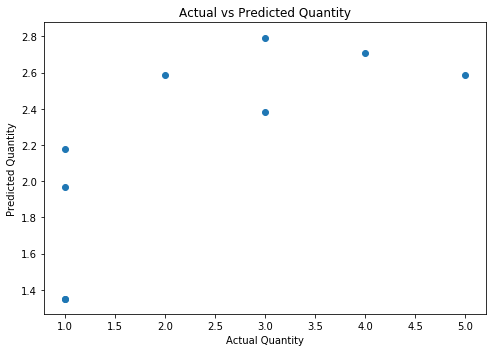

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Quantity")

plt.tight_layout()
plt.show()

In [76]:
regression_summary = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Target": ["Quantity"],
    "Predictor": ["Price Per Unit"],
    "MAE": [mae],
    "R2": [r2]
})

print(regression_summary)

               Model    Target       Predictor       MAE        R2
0  Linear Regression  Quantity  Price Per Unit  0.884972  0.398544


In [77]:
regression_summary.to_csv(
    r"C:\Users\HomePC\Downloads\regression_summary.csv",
    index=False
)

print("Regression summary saved successfully!")

Regression summary saved successfully!


In [78]:
import pyodbc
import pandas as pd

# Connect to SQL Server
server = "PC"
database = "Precious_Sales_Analysis"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=" + server + ";"
    "DATABASE=" + database + ";"
    "Trusted_Connection=yes;"
)

conn = pyodbc.connect(connection_string)
cursor = conn.cursor()

# Insert only records that are not already in sales_etl
insert_query = """
INSERT INTO sales_etl (
    transaction_id,
    customer_id,
    category,
    item,
    price_per_unit,
    quantity,
    total_spent,
    original_total_spent,
    payment_method,
    location,
    transaction_date
)
SELECT ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?
WHERE NOT EXISTS (
    SELECT 1
    FROM sales_etl
    WHERE transaction_id = ?
)
"""

loaded_count = 0

for _, row in clean_sales_final.iterrows():

    values = (
        row["transaction_id"],
        None if pd.isna(row["customer_id"]) else row["customer_id"],
        row["category"],
        row["item"],
        row["price_per_unit"],
        int(row["quantity"]),
        row["total_spent"],
        row["original_total_spent"],
        row["payment_method"],
        None if pd.isna(row["location"]) else row["location"],
        pd.to_datetime(row["transaction_date"]).date(),
        row["transaction_id"]
    )

    cursor.execute(insert_query, values)

    if cursor.rowcount > 0:
        loaded_count += 1

conn.commit()

print("ETL loading completed successfully!")
print("New records loaded:", loaded_count)

cursor.execute("SELECT COUNT(*) FROM sales_etl")
total_records = cursor.fetchone()[0]

print("Total records currently in sales_etl:", total_records)

ProgrammingError: ('42000', '[42000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]The incoming tabular data stream (TDS) remote procedure call (RPC) protocol stream is incorrect. Parameter 12 (""): The supplied value is not a valid instance of data type float. Check the source data for invalid values. An example of an invalid value is data of numeric type with scale greater than precision. (8023) (SQLExecDirectW)')

In [79]:
import pandas as pd
import pyodbc


def run_etl(input_file):
    
    # ==========================================
    # 1. EXTRACT
    # ==========================================
    raw_data = pd.read_csv(input_file)

    print("STEP 1: Data extracted")
    print("Raw records:", len(raw_data))


    # ==========================================
    # 2. STANDARDIZE COLUMN NAMES
    # ==========================================
    raw_data.columns = [
        str(column).strip().lower().replace(" ", "_")
        for column in raw_data.columns
    ]


    # ==========================================
    # 3. CLEAN TEXT DATA
    # ==========================================
    text_columns = [
        "customer_id",
        "category",
        "item",
        "payment_method",
        "location"
    ]

    for column in text_columns:
        raw_data[column] = raw_data[column].apply(
            lambda x: x.strip() if isinstance(x, str) else x
        )


    # ==========================================
    # 4. STANDARDIZE PAYMENT METHODS
    # ==========================================
    raw_data["payment_method"] = raw_data["payment_method"].apply(
        lambda x: x.lower() if isinstance(x, str) else x
    )

    payment_map = {
        "card": "Card",
        "cash": "Cash",
        "transfer": "Bank Transfer",
        "bank transfer": "Bank Transfer",
        "unknown": "Unknown"
    }

    raw_data["payment_method"] = raw_data[
        "payment_method"
    ].replace(payment_map)


    # ==========================================
    # 5. STANDARDIZE LOCATIONS
    # ==========================================
    raw_data["location"] = raw_data["location"].apply(
        lambda x: x.strip().title() if isinstance(x, str) else x
    )


    # ==========================================
    # 6. CONVERT NUMERIC COLUMNS
    # ==========================================
    numeric_columns = [
        "price_per_unit",
        "quantity",
        "total_spent"
    ]

    for column in numeric_columns:
        raw_data[column] = pd.to_numeric(
            raw_data[column],
            errors="coerce"
        )


    # ==========================================
    # 7. CONVERT DATES
    # ==========================================
    raw_data["transaction_date"] = pd.to_datetime(
        raw_data["transaction_date"],
        errors="coerce"
    )


    # ==========================================
    # 8. CALCULATE EXPECTED REVENUE
    # ==========================================
    raw_data["calculated_total"] = (
        raw_data["price_per_unit"]
        * raw_data["quantity"]
    )


    # ==========================================
    # 9. VALIDATE TOTALS
    # ==========================================
    raw_data["total_mismatch_flag"] = (
        raw_data["total_spent"].notna()
        & raw_data["calculated_total"].notna()
        & (
            raw_data["total_spent"]
            != raw_data["calculated_total"]
        )
    )


    # ==========================================
    # 10. VALIDATE MISSING DATA
    # ==========================================
    raw_data["missing_data_flag"] = (
        raw_data["price_per_unit"].isna()
        | raw_data["quantity"].isna()
        | raw_data["total_spent"].isna()
    )


    # ==========================================
    # 11. VALIDATE QUANTITY
    # ==========================================
    raw_data["invalid_quantity_flag"] = (
        raw_data["quantity"].notna()
        & (raw_data["quantity"] <= 0)
    )


    # ==========================================
    # 12. CREATE VALIDATION STATUS
    # ==========================================
    raw_data["validation_status"] = "Valid"

    raw_data.loc[
        raw_data["missing_data_flag"],
        "validation_status"
    ] = "Review - Missing Data"

    raw_data.loc[
        raw_data["invalid_quantity_flag"],
        "validation_status"
    ] = "Review - Invalid Quantity"

    raw_data.loc[
        raw_data["total_mismatch_flag"],
        "validation_status"
    ] = "Review - Total Mismatch"


    # ==========================================
    # 13. SEPARATE VALID AND REVIEW RECORDS
    # ==========================================
    clean_sales = raw_data[
        (raw_data["missing_data_flag"] == False)
        & (raw_data["invalid_quantity_flag"] == False)
        & (raw_data["total_mismatch_flag"] == False)
    ].copy()

    review_sales = raw_data[
        raw_data["validation_status"] != "Valid"
    ].copy()


    # ==========================================
    # 14. PRESERVE ORIGINAL TOTAL
    # ==========================================
    clean_sales["original_total_spent"] = (
        clean_sales["total_spent"]
    )


    # Use calculated total for validated records
    clean_sales["total_spent"] = (
        clean_sales["calculated_total"]
    )


    # ==========================================
    # 15. SELECT FINAL DATABASE COLUMNS
    # ==========================================
    final_columns = [
        "transaction_id",
        "customer_id",
        "category",
        "item",
        "price_per_unit",
        "quantity",
        "total_spent",
        "original_total_spent",
        "payment_method",
        "location",
        "transaction_date"
    ]

    clean_sales = clean_sales[final_columns].copy()


    # ==========================================
    # 16. EXPORT CLEAN DATA AND REVIEW QUEUE
    # ==========================================
    clean_sales.to_csv(
        r"C:\Users\HomePC\Downloads\Sales_ETL_Cleaned.csv",
        index=False
    )

    review_sales.to_csv(
        r"C:\Users\HomePC\Downloads\Sales_ETL_Review.csv",
        index=False
    )


    # ==========================================
    # 17. CONNECT TO SQL SERVER
    # ==========================================
    server = "PC"
    database = "Precious_Sales_Analysis"

    connection_string = (
        "DRIVER={ODBC Driver 17 for SQL Server};"
        "SERVER=" + server + ";"
        "DATABASE=" + database + ";"
        "Trusted_Connection=yes;"
    )

    conn = pyodbc.connect(connection_string)
    cursor = conn.cursor()


    # ==========================================
    # 18. LOAD VALIDATED DATA INTO SQL SERVER
    # ==========================================
    insert_query = """
    INSERT INTO sales_etl (
        transaction_id,
        customer_id,
        category,
        item,
        price_per_unit,
        quantity,
        total_spent,
        original_total_spent,
        payment_method,
        location,
        transaction_date
    )
    SELECT ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?
    WHERE NOT EXISTS (
        SELECT 1
        FROM sales_etl
        WHERE transaction_id = ?
    )
    """

    loaded_count = 0

    for _, row in clean_sales.iterrows():

        values = (
            row["transaction_id"],
            None if pd.isna(row["customer_id"])
            else row["customer_id"],
            row["category"],
            row["item"],
            row["price_per_unit"],
            int(row["quantity"]),
            row["total_spent"],
            row["original_total_spent"],
            row["payment_method"],
            None if pd.isna(row["location"])
            else row["location"],
            pd.to_datetime(
                row["transaction_date"]
            ).date(),
            row["transaction_id"]
        )

        cursor.execute(insert_query, values)

        if cursor.rowcount > 0:
            loaded_count += 1

    conn.commit()


    # ==========================================
    # 19. FINAL REPORT
    # ==========================================
    cursor.execute("SELECT COUNT(*) FROM sales_etl")
    database_count = cursor.fetchone()[0]

    conn.close()

    print("\nETL PROCESS COMPLETED")
    print("----------------------------")
    print("Raw records:", len(raw_data))
    print("Valid records:", len(clean_sales))
    print("Records requiring review:", len(review_sales))
    print("New records loaded:", loaded_count)
    print("Total records in sales_etl:", database_count)


# ==========================================
# RUN THE ETL PIPELINE
# ==========================================

input_file = r"C:\Users\HomePC\Downloads\dirty_retail_sales_50_rows.csv"

run_etl(input_file)

STEP 1: Data extracted
Raw records: 50

ETL PROCESS COMPLETED
----------------------------
Raw records: 50
Valid records: 41
Records requiring review: 9
New records loaded: 0
Total records in sales_etl: 41


In [80]:
# Load the SQL reporting views into Python

category_report = pd.read_sql(
    "SELECT * FROM vw_sales_by_category",
    conn
)

monthly_report = pd.read_sql(
    "SELECT * FROM vw_monthly_sales",
    conn
)

product_report = pd.read_sql(
    "SELECT * FROM vw_product_performance",
    conn
)

location_report = pd.read_sql(
    "SELECT * FROM vw_sales_by_location",
    conn
)

payment_report = pd.read_sql(
    "SELECT * FROM vw_sales_by_payment_method",
    conn
)

print("Reporting views loaded successfully!")

print("\nCategory Report:")
print(category_report)

print("\nMonthly Report:")
print(monthly_report)

print("\nProduct Report:")
print(product_report.head())

print("\nLocation Report:")
print(location_report)

print("\nPayment Report:")
print(payment_report)

Reporting views loaded successfully!

Category Report:
      category  transaction_count  units_sold  total_revenue  \
0       Beauty                  4          11        74000.0   
1     Clothing                  4           5        57000.0   
2  Electronics                  9          23       128500.0   
3         Food                 13          31       287500.0   
4         Home                 11          25       151500.0   

   average_transaction_value  
0               18500.000000  
1               14250.000000  
2               14277.777777  
3               22115.384615  
4               13772.727272  

Monthly Report:
   sales_year  sales_month  transaction_count  units_sold  total_revenue  \
0        2026            1                  5          10        68500.0   
1        2026            2                  7          13       145000.0   
2        2026            3                 10          27       184500.0   
3        2026            4                  7        

In [81]:
# Create an automated KPI summary from the SQL ETL table

kpi_query = """
SELECT
    COUNT(*) AS total_transactions,
    SUM(quantity) AS total_units_sold,
    SUM(total_spent) AS total_revenue,
    AVG(total_spent) AS average_transaction_value,
    COUNT(DISTINCT customer_id) AS unique_customers,
    COUNT(DISTINCT item) AS unique_products,
    COUNT(DISTINCT location) AS locations
FROM sales_etl;
"""

kpi_summary = pd.read_sql(kpi_query, conn)

print("KPI Summary:")
print(kpi_summary)

KPI Summary:
   total_transactions  total_units_sold  total_revenue  \
0                  41                95       698500.0   

   average_transaction_value  unique_customers  unique_products  locations  
0               17036.585365                22               20          4  


In [82]:
kpi_file = r"C:\Users\HomePC\Downloads\Sales_KPI_Report.csv"

kpi_summary.to_csv(
    kpi_file,
    index=False
)

print("KPI report saved successfully!")
print("File:", kpi_file)

KPI report saved successfully!
File: C:\Users\HomePC\Downloads\Sales_KPI_Report.csv


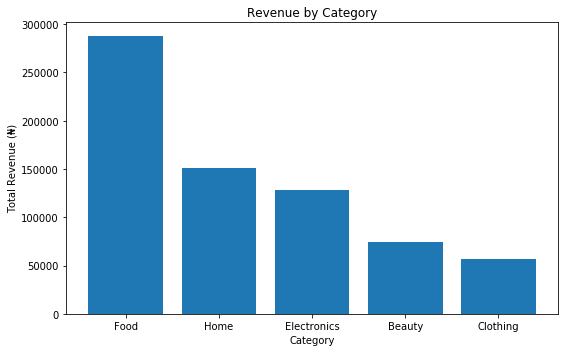

In [83]:
import matplotlib.pyplot as plt

category_report_sorted = category_report.sort_values(
    "total_revenue",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    category_report_sorted["category"],
    category_report_sorted["total_revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (₦)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

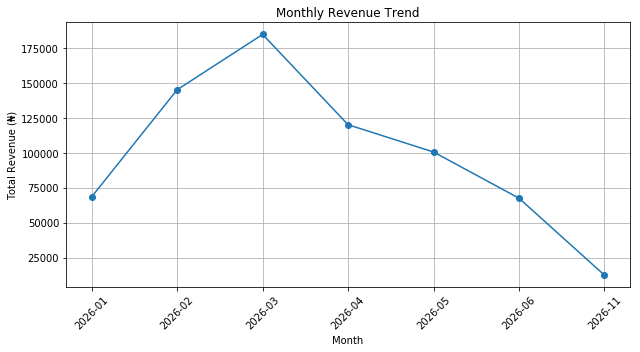

In [84]:
monthly_report["month"] = (
    monthly_report["sales_year"].astype(str)
    + "-"
    + monthly_report["sales_month"].astype(str).str.zfill(2)
)

monthly_report = monthly_report.sort_values(
    ["sales_year", "sales_month"]
)

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_report["month"],
    monthly_report["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₦)")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

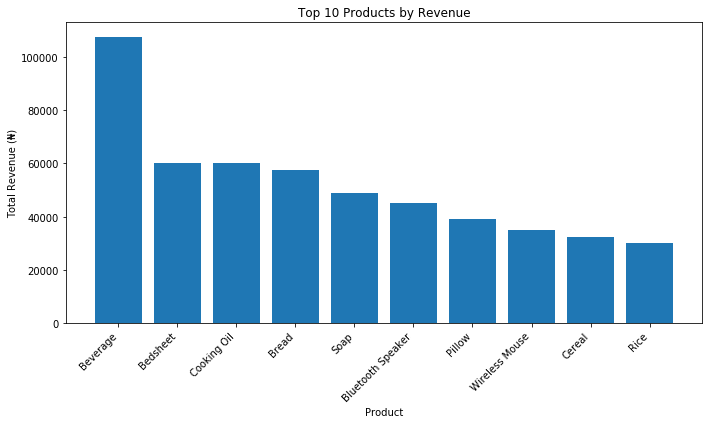

In [85]:
top_products = product_report.sort_values(
    "total_revenue",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_products["item"],
    top_products["total_revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue (₦)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

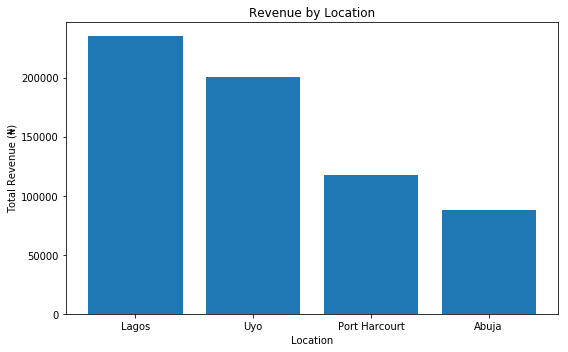

In [86]:
location_report_sorted = location_report.dropna(
    subset=["location"]
).sort_values(
    "total_revenue",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    location_report_sorted["location"],
    location_report_sorted["total_revenue"]
)

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Total Revenue (₦)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
run_etl(input_file)

STEP 1: Data extracted
Raw records: 50

ETL PROCESS COMPLETED
----------------------------
Raw records: 50
Valid records: 41
Records requiring review: 9
New records loaded: 0
Total records in sales_etl: 41


# Automated Retail Sales Analytics System

## An End-to-End Data Analytics Project

**Tools:** Excel, Python, Pandas, SQL Server, SQL, Jupyter Notebook, Power BI

**Project Focus:** Data Cleaning, ETL, SQL Analytics, Statistical Analysis, Regression, and Business Intelligence

## 1. Project Overview

The Automated Retail Sales Analytics System is an end-to-end data analytics project designed to transform raw retail sales data into reliable, actionable business insights.

The project begins with raw sales data containing missing values, inconsistent formats, invalid quantities, and incorrect transaction totals. Python is used to clean and validate the data through an automated ETL process. The validated records are then loaded into a SQL Server database for structured storage and analysis.

Python is also used for exploratory data analysis, correlation analysis, and regression modelling. Power BI connects to the validated sales data to provide an interactive dashboard for monitoring revenue, transactions, units sold, products, categories, locations, and payment methods.

The overall workflow is:

Raw Data → Python ETL → Data Validation → SQL Server → SQL Analysis → Python Analysis → Power BI Dashboard

## 2. Business Problem

Retail businesses generate large volumes of transactional data, but raw sales records are not always ready for analysis.

The dataset used in this project contains several data quality issues, including missing values, inconsistent text formats, invalid quantities, mixed date formats, and incorrect transaction totals.

If these issues are not identified and handled properly, they can lead to inaccurate revenue calculations, misleading reports, and unreliable business decisions.

This project addresses the problem by developing an automated data pipeline that cleans, validates, stores, analyzes, and visualizes retail sales data.

The system is designed to provide reliable sales information that can support business monitoring and data-driven decision making.

## 3. Project Objectives

The objectives of this project are to:

1. Clean and standardize raw retail sales data using Python and Pandas.

2. Identify and validate data quality issues such as missing values, duplicate records, invalid quantities, and incorrect transaction totals.

3. Develop an automated ETL process for transforming and loading validated sales records.

4. Store validated sales data in a structured SQL Server database.

5. Use SQL to perform sales analysis and generate reporting datasets.

6. Use Python to perform exploratory data analysis, correlation analysis, and regression modelling.

7. Develop an interactive Power BI dashboard for monitoring key sales performance indicators.

8. Create a reproducible end-to-end analytics workflow that can be rerun when new sales data becomes available.

9. Present meaningful business insights from the analyzed sales data.

## 4. Tools and Technologies

The project uses the following tools and technologies:

| Tool / Technology | Purpose |
|---|---|
| Excel / CSV | Initial sales data source and raw data storage |
| Python | Data cleaning, transformation, validation, ETL, and analysis |
| Pandas | Data manipulation and preprocessing |
| Jupyter Notebook | Development environment and project documentation |
| SQL Server | Central relational database for validated sales data |
| SQL | Data querying, validation, aggregation, and reporting |
| PyODBC | Connection between Python and SQL Server |
| Scikit-learn | Regression modelling and model evaluation |
| Power BI | Interactive data visualization and dashboard development |
| DAX | Power BI measures and dynamic KPI calculations |
| GitHub | Project version control and portfolio documentation |

## 5. Dataset Description

The project uses a retail sales transaction dataset containing 50 raw transaction records.

Each record represents a sales transaction and contains information about the transaction, customer, product, pricing, quantity, payment method, location, and transaction date.

### Dataset Fields

| Column | Description |
|---|---|
| Transaction_ID | Unique identifier for each transaction |
| Customer_ID | Identifier for the customer |
| Category | Product category |
| Item | Product purchased |
| Price_Per_Unit | Price of one unit of the product |
| Quantity | Number of units purchased |
| Total_Spent | Reported transaction amount |
| Payment_Method | Method used to make payment |
| Location | Customer or transaction location |
| Transaction_Date | Date of the transaction |

### Initial Dataset Size

- Raw records: 50
- Raw columns: 10
- Validated records loaded into SQL Server: 41
- Records requiring review: 9

The reduction from 50 raw records to 41 validated records was the result of the data quality rules applied during the ETL process. Records with unresolved missing values, invalid quantities, or transaction-total inconsistencies were placed in a review queue rather than being loaded as valid sales transactions.

## 6. Data Quality Assessment

An initial assessment of the raw dataset was performed before cleaning and transformation.

The assessment identified the following data quality issues:

| Data Quality Issue | Records Affected | Treatment |
|---|---:|---|
| Missing Customer_ID | 2 | Retained as missing and flagged for review |
| Missing Price_Per_Unit | 3 | Excluded from validated sales |
| Missing Quantity | 2 | Excluded from validated sales |
| Missing Total_Spent | 2 | Excluded from validated sales |
| Missing Location | 2 | Retained as missing in validated data |
| Invalid Quantity | 1 | Flagged for review |
| Incorrect Total_Spent | 2 | Validated using Price_Per_Unit × Quantity |
| Inconsistent Payment_Method values | Multiple | Standardized |
| Inconsistent Location capitalization | Multiple | Standardized |
| Mixed date formats | Multiple | Converted to a consistent date format |

### Validation Rules

The ETL process applied the following validation rules:

- Transaction IDs must be unique.
- Quantity must be greater than zero for a valid sale.
- Price per unit must be available.
- Quantity must be available.
- Total spent must be available.
- Calculated transaction value must be validated against the reported total.
- Text fields must be standardized.
- Transaction dates must be converted to a consistent date format.

Records that failed the validation rules were separated into a review queue instead of being silently deleted.

This approach preserves data integrity and provides an audit trail for records requiring further investigation.

## 7. Data Cleaning and Transformation

Python and Pandas were used to clean and standardize the raw sales data before loading it into the database.

### Cleaning Steps

1. Column names were standardized to lowercase and converted to a consistent naming convention.

2. Leading and trailing spaces were removed from text fields.

3. Payment methods were standardized.
   - `card` and `Card` were standardized to `Card`.
   - `cash` and `Cash` were standardized to `Cash`.
   - `Transfer` and `Bank Transfer` were standardized to `Bank Transfer`.
   - `UNKNOWN` was standardized to `Unknown`.

4. Location values were standardized to consistent capitalization.

5. Numeric columns were converted to appropriate numeric data types.

6. Transaction dates were converted to a consistent date format.

7. An expected transaction total was calculated using:

   **Calculated Total = Price Per Unit × Quantity**

8. Reported transaction totals were compared with calculated totals to identify inconsistencies.

9. Records with missing or invalid information were separated into a review queue.

10. Valid records were prepared for loading into SQL Server.

### Data Integrity

The original raw data was preserved separately from the cleaned dataset. This ensures that the cleaning process does not overwrite the source data and allows the transformation process to be audited or repeated.

## 8. ETL Pipeline

The project uses an automated ETL (Extract, Transform, Load) process to move raw sales data into the SQL Server database.

### Extract

The process reads the raw sales CSV file into Python using Pandas.

```python
raw_data = pd.read_csv(input_file)

## 9. SQL Server Database

The validated sales data is stored in a Microsoft SQL Server database named:

**Precious_Sales_Analysis**

The main ETL table is:

**sales_etl**

### Database Structure

The `sales_etl` table contains the following fields:

| Column | Data Type | Purpose |
|---|---|---|
| transaction_id | VARCHAR | Unique transaction identifier |
| customer_id | VARCHAR | Customer identifier |
| category | VARCHAR | Product category |
| item | VARCHAR | Product name |
| price_per_unit | DECIMAL | Unit selling price |
| quantity | INT | Quantity sold |
| total_spent | DECIMAL | Validated transaction value |
| original_total_spent | DECIMAL | Original reported transaction value |
| payment_method | VARCHAR | Payment method |
| location | VARCHAR | Sales location |
| transaction_date | DATE | Transaction date |

### Database Validation

The final ETL table contains:

- **41 validated transactions**
- **95 units sold**
- **₦698,500 total revenue**

The database was also tested after rerunning the ETL process. The record count remained at 41, confirming that duplicate transactions were not created.

## 10. SQL Analysis

SQL Server was used to analyze the validated sales transactions and generate reporting datasets.

The analysis focused on revenue, transaction volume, products, categories, locations, payment methods, and monthly performance.

### Key SQL Analysis Areas

#### Overall Performance

- Total transactions: **41**
- Total units sold: **95**
- Total revenue: **₦698,500**
- Average transaction value: **₦17,037**

#### Revenue by Category

Revenue was grouped by product category to compare category-level performance.

#### Revenue by Location

Revenue was grouped by location to understand the distribution of sales across different locations.

#### Product Performance

Products were analyzed based on:

- Units sold
- Total revenue
- Average transaction value

#### Monthly Sales

Transactions were grouped by year and month to identify revenue patterns over time.

#### Payment Method

Sales were grouped by payment method to understand transaction volume and revenue by payment type.

### SQL Reporting Views

The following SQL views were created to support reporting and Power BI:

- `vw_sales_by_category`
- `vw_monthly_sales`
- `vw_product_performance`
- `vw_sales_by_location`
- `vw_sales_by_payment_method`

These views provide structured reporting datasets while keeping the analytical logic inside the database.

## 11. Exploratory Data Analysis

Python and Pandas were used to explore the validated sales data and identify patterns in the dataset.

The analysis examined:

- Dataset structure and data types
- Missing values
- Descriptive statistics
- Revenue by category
- Revenue by location
- Product performance
- Monthly revenue
- Payment method distribution

### Descriptive Statistics

The validated dataset contains 41 sales transactions.

| Metric | Result |
|---|---:|
| Average price per unit | ₦8,840.91 |
| Average quantity per transaction | 2.30 units |
| Average transaction value | ₦17,036.59 |
| Minimum transaction value | ₦2,500 |
| Maximum transaction value | ₦60,000 |

### Revenue by Category

The validated data shows the following revenue distribution:

| Category | Revenue |
|---|---:|
| Food | ₦287,500 |
| Home | ₦151,500 |
| Electronics | ₦128,500 |
| Beauty | ₦74,000 |
| Clothing | ₦57,000 |

### Revenue by Location

| Location | Revenue |
|---|---:|
| Lagos | ₦235,000 |
| Uyo | ₦200,500 |
| Port Harcourt | ₦117,500 |
| Abuja | ₦88,000 |
| Missing Location | ₦57,500 |

The missing-location records are retained in the validated dataset rather than being assigned an artificial location.

### Monthly Revenue

Revenue was analyzed by month to identify changes in sales activity across the available transaction dates.

The highest recorded monthly revenue was **₦184,500 in March 2026**.

The dataset contains transactions in January through June and November 2026. The absence of transactions between July and October should not be interpreted as a confirmed period of zero sales for the business because the dataset may not represent the complete sales history for those months.

## 12. Correlation Analysis

Correlation analysis was performed using Python to examine the linear relationships between price per unit, quantity, and total transaction value.

### Correlation Matrix

| Variable | Price Per Unit | Quantity | Total Spent |
|---|---:|---:|---:|
| Price Per Unit | 1.000 | -0.447 | 0.472 |
| Quantity | -0.447 | 1.000 | 0.441 |
| Total Spent | 0.472 | 0.441 | 1.000 |

### Interpretation

The correlation between **Price Per Unit and Quantity** is approximately **-0.447**, indicating a moderate negative linear relationship in this sample.

The correlation between **Price Per Unit and Total Spent** is approximately **0.472**, indicating a moderate positive linear relationship.

The correlation between **Quantity and Total Spent** is approximately **0.441**, also indicating a moderate positive linear relationship.

Correlation measures association and does not establish causation.

It is also important to note that `Total Spent` is calculated from price and quantity. Therefore, correlations involving Total Spent are partly influenced by the mathematical relationship:

**Total Spent = Price Per Unit × Quantity**

The correlation results should therefore be interpreted as descriptive relationships within this dataset rather than evidence of causal effects.

## 13. Regression Analysis

A simple linear regression model was developed using Python and Scikit-learn to examine whether Price Per Unit could be used to predict Quantity Sold.

### Model Definition

- **Predictor (X):** Price Per Unit
- **Target (y):** Quantity
- **Model:** Linear Regression
- **Records used:** 41 clean sales records
- **Training records:** 32
- **Testing records:** 9

The regression model estimates Quantity using the relationship:

**Quantity = Intercept + Coefficient × Price Per Unit**

### Model Results

| Metric | Result |
|---|---:|
| Mean Absolute Error (MAE) | 0.842 |
| R² Score | 0.383 |

### Interpretation

The model produced an MAE of approximately **0.84 units**, meaning that the model's predictions differed from the actual quantity by about 0.84 units on average on the test data.

The R² score of approximately **0.383** indicates that the model explains about 38.3% of the variation in quantity within the test dataset.

The model provides some predictive information, but a substantial portion of the variation in quantity remains unexplained.

The results should be interpreted cautiously because the dataset is relatively small and the model uses only Price Per Unit as the predictor. A stronger predictive model would require more observations and potentially additional relevant variables.

## 14. Power BI Dashboard

Power BI was used to develop an interactive dashboard connected to the validated `sales_etl` transaction table.

The dashboard provides a consolidated view of retail sales performance.

### Key Performance Indicators

The dashboard displays four primary KPIs:

- **Total Revenue:** ₦698,500
- **Total Transactions:** 41
- **Total Units Sold:** 95
- **Average Transaction Value:** ₦17,037

### Dashboard Visuals

The dashboard contains the following analytical visuals:

1. **Monthly Revenue Trend**
   - Shows revenue across the available transaction months.

2. **Top 10 Products by Revenue**
   - Identifies the ten products generating the highest revenue.

3. **Revenue by Category**
   - Compares revenue across product categories.

4. **Revenue by Location**
   - Shows revenue distribution across sales locations.

5. **Revenue by Payment Method**
   - Compares revenue generated through different payment methods.

### Interactive Filters

Two slicers were added to the dashboard:

- **Location**
- **Payment Method**

The slicers are connected to the transaction-level `sales_etl` table. Selecting a location or payment method dynamically updates the KPI cards and analytical visuals.

This allows users to explore the sales data interactively rather than relying only on static reports.

## 15. Key Findings

The analysis of the validated retail sales data produced the following findings:

### Overall Sales Performance

- The dataset contains **41 validated transactions**.
- A total of **95 units** were sold.
- Total validated revenue was **₦698,500**.
- The average transaction value was approximately **₦17,037**.

### Category Performance

Food generated the highest revenue among the product categories, with **₦287,500** in validated revenue.

Home generated **₦151,500**, while Electronics generated **₦128,500**.

### Location Performance

Lagos generated **₦235,000** in validated revenue, followed by Uyo with **₦200,500**.

Port Harcourt generated **₦117,500**, while Abuja generated **₦88,000**.

There were also **₦57,500** in transactions with missing location information.

### Monthly Performance

March 2026 recorded the highest monthly revenue in the available dataset, with **₦184,500**.

The available data contains transactions from January through June and November 2026.

### Product Performance

The product analysis shows that revenue is distributed across a range of products, with some products contributing significantly more revenue than others.

The Power BI Top 10 Products visual provides an interactive view of the highest-revenue products.

### Data Quality

The project identified several issues in the raw data. Rather than silently removing questionable records, the ETL process separated them into a review queue.

This resulted in **41 validated records** and **9 records requiring review**.

## 16. Business Recommendations

Based on the analysis performed in this project, the following recommendations can be considered:

1. **Monitor category-level performance**
   
   Sales performance should be reviewed by category regularly to understand which categories contribute most to revenue and which may require further attention.

2. **Investigate location-level differences**
   
   Revenue varies across locations. Businesses can investigate the factors behind these differences, such as customer demand, product availability, pricing, and transaction volume.

3. **Monitor product performance**
   
   The Top 10 Products report can be used to identify high-revenue products and monitor their performance over time.

4. **Improve data capture**
   
   Missing customer and location information should be addressed at the point of data entry to improve the completeness of future analysis.

5. **Investigate data quality exceptions**
   
   Transactions placed in the review queue should be examined before being included in official sales reporting.

6. **Use the dashboard for continuous monitoring**
   
   The Power BI dashboard can be refreshed as new validated sales data becomes available, allowing management to monitor key sales indicators over time.

7. **Expand predictive analysis with more data**
   
   Future versions of the project could incorporate additional predictors and a larger historical dataset to develop more robust predictive models.

## 17. Project Limitations

The following limitations should be considered when interpreting the results:

1. **Small dataset size**

   The validated dataset contains 41 transactions. This is sufficient for demonstrating the analytics workflow, but it is relatively small for making broad business conclusions or building highly reliable predictive models.

2. **Incomplete historical coverage**

   The available transactions occur in selected months of 2026. The absence of transactions in some months cannot be interpreted as confirmed zero sales without a complete sales history.

3. **Missing values**

   Some validated transactions still contain missing Customer_ID and Location values. These records were retained where they did not violate the sales validation rules.

4. **Regression limitations**

   The regression model uses Price Per Unit as the predictor of Quantity. Other factors that may influence quantity, such as customer behavior, product type, promotions, seasonality, and location, were not included in the simple model.

5. **Correlation limitations**

   Correlation measures association rather than causation. In addition, Total Spent is mathematically derived from Price Per Unit and Quantity, so correlations involving Total Spent should be interpreted carefully.

6. **Data quality review**

   Nine raw records were excluded from the validated sales table and placed in a review queue. Further investigation of these records could potentially increase the amount of usable data.

## 18. Conclusion

The Automated Retail Sales Analytics System successfully demonstrates an end-to-end data analytics workflow, from raw data collection and data quality assessment to automated transformation, database storage, statistical analysis, and interactive visualization.

Python and Pandas were used to clean and validate the raw sales data and implement an automated ETL process. SQL Server was used as the central database for storing validated transactions and generating structured reporting datasets.

Python was further used for exploratory data analysis, correlation analysis, and regression modelling. Power BI was then used to transform the validated data into an interactive sales dashboard containing key performance indicators, trends, product analysis, category analysis, location analysis, and payment-method analysis.

The final system successfully processed 50 raw records, validated 41 sales transactions, and maintained 41 records in the SQL Server database after an ETL rerun without creating duplicates.

The project demonstrates how Excel/CSV data, Python, SQL Server, statistical analysis, and Power BI can be combined to create a reproducible retail sales analytics workflow.

## 19. Project Workflow

The complete system follows this workflow:

Raw Sales Data
↓
Python Data Extraction
↓
Data Cleaning and Standardization
↓
Data Quality Validation
↓
ETL Processing
↓
SQL Server Database
↓
SQL Analysis and Reporting Views
↓
Python Exploratory Analysis
↓
Correlation Analysis
↓
Regression Analysis
↓
Power BI Dashboard
↓
Business Insights and Reporting

### End-to-End Architecture

The project separates the data pipeline into distinct stages:

**Source Layer**
- Raw CSV/Excel sales data

**Transformation Layer**
- Python
- Pandas
- Data validation
- ETL

**Storage Layer**
- SQL Server
- `sales_etl`

**Analytics Layer**
- SQL
- Python
- Correlation
- Regression

**Presentation Layer**
- Power BI
- Interactive KPIs
- Charts
- Slicers